EDA->feature engg->clean data->applying model->hyperparameter tuning

## Algerian Forest Fires Dataset 
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import seaborn as sns

In [2]:
dataset=pd.read_csv('Algerian_forest_fires_dataset.csv')

In [3]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.1 KB


DATA cleaning

In [5]:
dataset.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
dtype: int64

In [6]:
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
123,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,14,7,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [7]:
df=dataset

In [8]:
df.loc[:123,'region']=0
df.loc[123:,'region']=1

In [10]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
242,26,9,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1.0
243,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1.0
244,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1.0
245,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1.0
246,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,not fire,1.0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    str    
 1   month        245 non-null    str    
 2   year         245 non-null    str    
 3   Temperature  245 non-null    str    
 4    RH          245 non-null    str    
 5    Ws          245 non-null    str    
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
 14  region       247 non-null    float64
dtypes: float64(1), str(14)
memory usage: 29.1 KB


In [17]:
df[['region']]=df[['region']].astype(int)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
 14  region       247 non-null    int64
dtypes: int64(1), str(14)
memory usage: 29.1 KB


In [19]:
df.isnull().sum()

day            1
month          2
year           2
Temperature    2
 RH            2
 Ws            2
Rain           2
FFMC           2
DMC            2
DC             2
ISI            2
BUI            2
FWI            2
Classes        3
region         0
dtype: int64

In [40]:
df=df.dropna().reset_index(drop=True)

In [29]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
region         0
dtype: int64

In [41]:
df.head()

,level_0,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,0,0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,2,2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,4,4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [42]:
df.shape

(244, 17)

In [54]:
df.iloc[[122]]# so we need to drop this row because it is repeted 

,level_0,index,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,122,122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [63]:
df=df.drop(122).reset_index(drop=True)

In [60]:
df =df.drop("level_0",axis=1)

In [59]:
df =df.drop("index",axis=1)

In [61]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
df.iloc[[122]]#122th row has been removed

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
122,1,6,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [67]:
df.columns# here we will fix the spaces inthe column names

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'region'],
      dtype='str')

In [68]:
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'region'],
      dtype='str')

In [ ]:
#changing the required colums to the req into "int" data types

In [69]:
df[['day', 'month', 'year', 'Temperature','RH', 'Ws']]=df[['day', 'month', 'year', 'Temperature','RH', 'Ws']].astype(int)

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  region       243 non-null    int64
dtypes: int64(7), str(8)
memory usage: 28.6 KB


In [79]:
objects=[features for features in  df.columns if df[features].dtypes=='str']

In [80]:
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

In [88]:
for i in objects:
    if i!='Classes':
        df[i]=df[i].astype(float)
        

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 28.6 KB


In [91]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.600823,77.403292,14.209877,49.020576,4.329218,16.222222,6.600823,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,1.915875,14.370033,12.391062,47.679582,4.141936,14.243746,7.444639,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.000000,0.000000,6.000000,0.000000,1.000000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.500000,5.000000,12.000000,1.000000,6.000000,0.000000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.000000,11.000000,33.000000,3.000000,12.000000,4.000000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.000000,88.000000,20.000000,69.000000,7.000000,22.000000,11.000000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.000000,96.000000,65.000000,220.000000,19.000000,68.000000,31.000000,1.000000


In [94]:
#now we will save the clead data set 
df.to_csv('Algerian_forest_fires_dataset_cleaned_set_1.csv',index=False)

#expolataryt data analysis

In [96]:
df_copy=df

In [97]:
df_copy

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,6,2012,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,not fire,0
1,2,6,2012,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,not fire,0
2,3,6,2012,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,not fire,0
3,4,6,2012,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,6.0,fire,1
239,27,9,2012,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0.0,not fire,1
240,28,9,2012,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0.0,not fire,1
241,29,9,2012,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0.0,not fire,1


In [100]:
#here we will drop day,month,year its required for analysis
df_copy=df_copy.drop(['day', 'month', 'year'],axis=1)

In [ ]:
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,not fire,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,not fire,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,not fire,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,not fire,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,6.0,fire,1
239,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0.0,not fire,1
240,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0.0,not fire,1
241,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0.0,not fire,1


In [102]:
# now here we will do the encoding for to change the classes "fire" and "not fire"
df_copy['Classes']=np.where(df_copy['Classes']=='not fire',0,1)


In [ ]:
df_copy # in this solution because of spaceing in "fire"or"fire " and "not fire"  it willshoe invalid result

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,1,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,1,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,1,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,1,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,6.0,1,1
239,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0.0,1,1
240,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0.0,1,1
241,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0.0,1,1


In [105]:
df_copy_1=df

In [108]:
df_copy=df_copy.drop(["Classes"],axis=1)

In [110]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,region
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,0


In [112]:
df_copy["Classes"]=df["Classes"]

In [115]:
df_copy.head(1)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,region,Classes
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,0,0


In [114]:
# now here we will do the encoding for to change the classes "fire" and "not fire"
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)


In [117]:
df_copy

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,region,Classes
0,29,57,18,0.0,65.0,3.0,7.0,1.0,3.0,0.0,0,0
1,29,61,13,1.0,64.0,4.0,7.0,1.0,3.0,0.0,0,0
2,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,0,0
3,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,0,0
4,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
238,30,65,14,0.0,85.0,16.0,44.0,4.0,16.0,6.0,1,1
239,28,87,15,4.0,41.0,6.0,8.0,0.0,6.0,0.0,1,0
240,27,87,29,0.0,45.0,3.0,7.0,0.0,3.0,0.0,1,0
241,24,54,18,0.0,79.0,4.0,15.0,1.0,5.0,0.0,1,0


In [118]:
df_copy["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

array([[<Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'RH'}>, <Axes: title={'center': 'Ws'}>],
       [<Axes: title={'center': 'Rain'}>,
        <Axes: title={'center': 'FFMC'}>,
        <Axes: title={'center': 'DMC'}>],
       [<Axes: title={'center': 'DC'}>, <Axes: title={'center': 'ISI'}>,
        <Axes: title={'center': 'BUI'}>],
       [<Axes: title={'center': 'FWI'}>,
        <Axes: title={'center': 'region'}>,
        <Axes: title={'center': 'Classes'}>]], dtype=object)

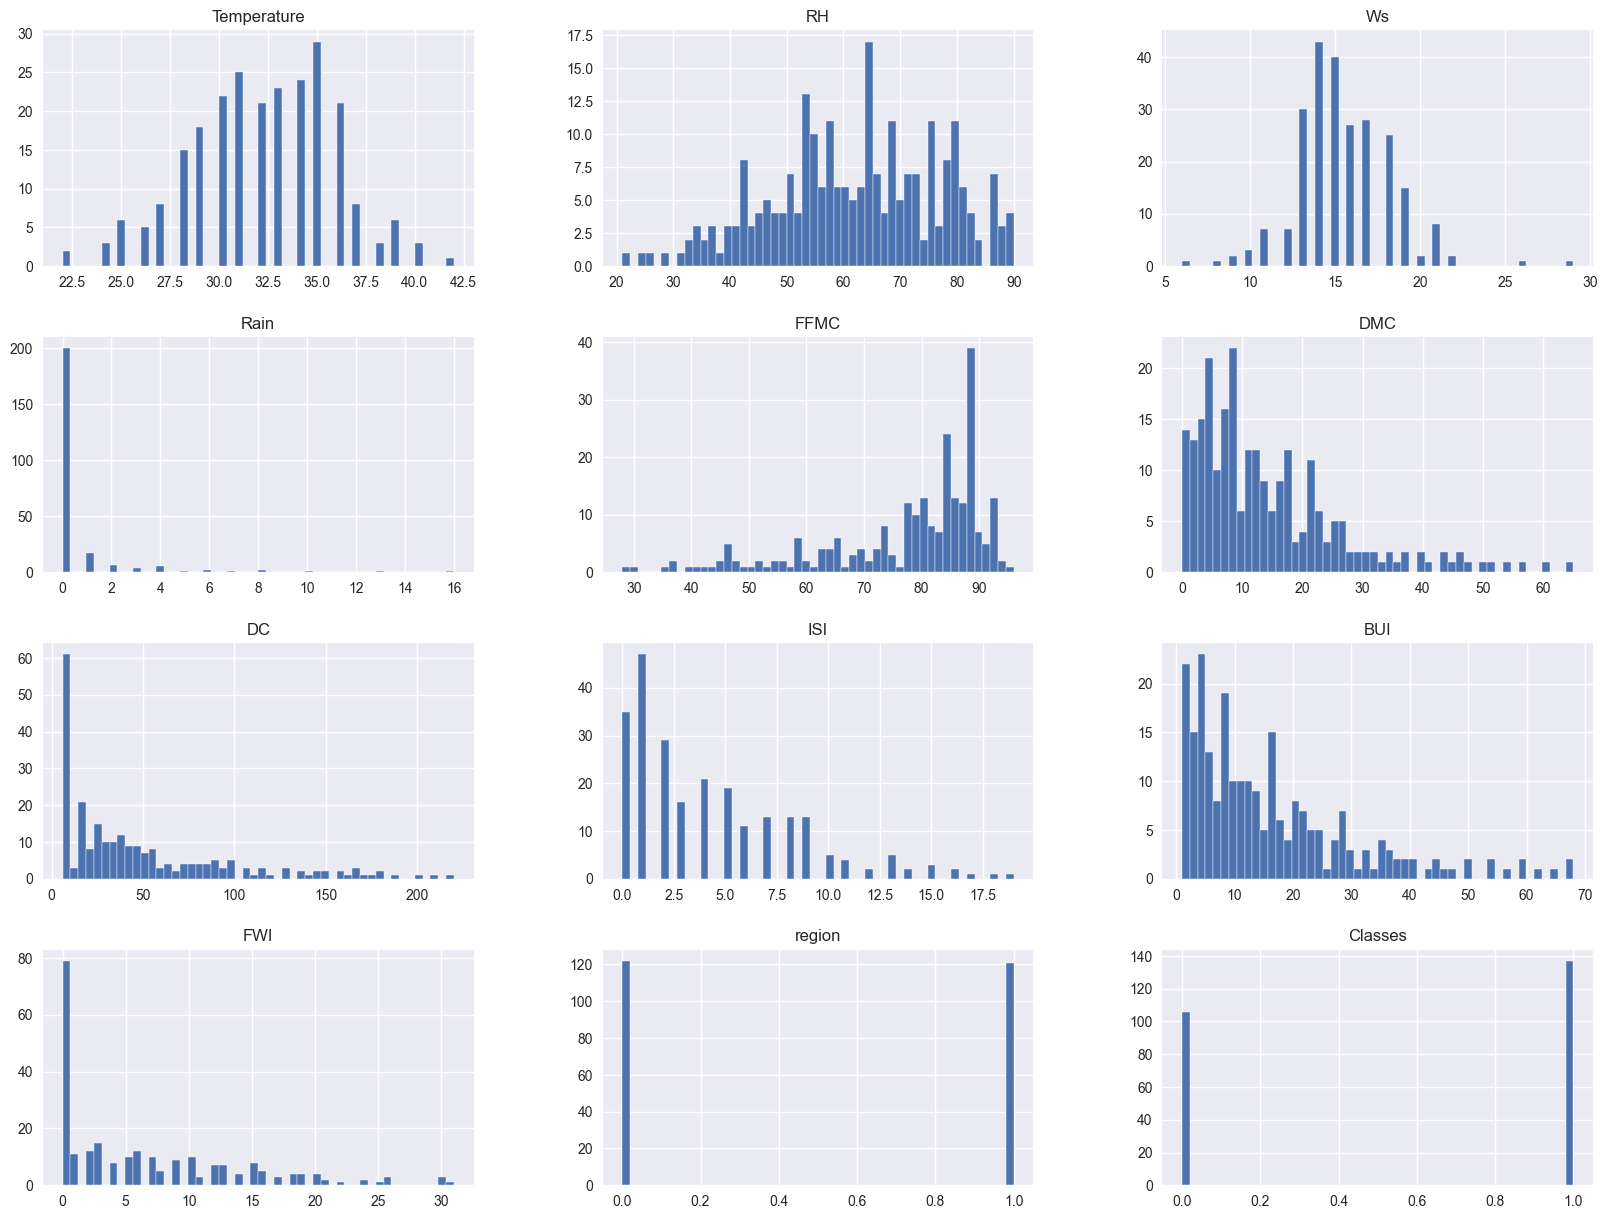

In [128]:
#ploting density plot for all the features
sns.set_style("darkgrid")
df_copy.hist(bins=50,figsize=(20,15))

In [134]:
percentage=df_copy['Classes'].value_counts(normalize=True)*100

<function matplotlib.pyplot.show(close=None, block=None)>

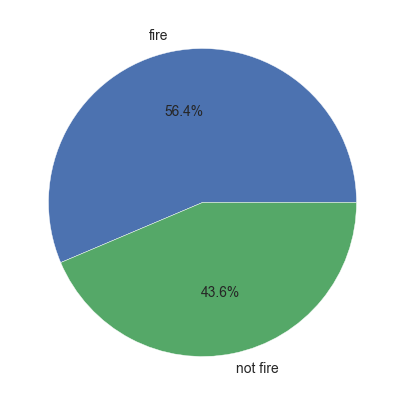

In [135]:
#now here we will plot a pie chart for Classes
classlabels=['fire','not fire']
plt.figure(figsize=(10,5))
plt.pie(percentage,labels=classlabels,autopct="%1.1f%%")
plt.show

In [136]:
#correlation and multi colinearlity
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,region,Classes
Temperature,1.000000,-0.651400,-0.284510,-0.322351,0.677443,0.485904,0.376003,0.601893,0.457610,0.561140,0.269555,0.516015
RH,-0.651400,1.000000,0.244048,0.212946,-0.644674,-0.409140,-0.226695,-0.685212,-0.350936,-0.573959,-0.402682,-0.432161
Ws,-0.284510,0.244048,1.000000,0.170238,-0.166354,0.000571,0.078934,0.005143,0.031714,0.037493,-0.181160,-0.069964
Rain,-0.322351,0.212946,0.170238,1.000000,-0.496339,-0.253027,-0.268250,-0.294768,-0.265361,-0.270804,-0.033145,-0.326876
FFMC,0.677443,-0.644674,-0.166354,-0.496339,1.000000,0.604157,0.507689,0.729235,0.592232,0.679905,0.222804,0.768896
DMC,0.485904,-0.409140,0.000571,-0.253027,0.604157,1.000000,0.875447,0.680604,0.981594,0.875854,0.191430,0.584676
DC,0.376003,-0.226695,0.078934,-0.268250,0.507689,0.875447,1.000000,0.502481,0.941716,0.738373,-0.078271,0.510853
ISI,0.601893,-0.685212,0.005143,-0.294768,0.729235,0.680604,0.502481,1.000000,0.640407,0.918229,0.269143,0.728555
BUI,0.457610,-0.350936,0.031714,-0.265361,0.592232,0.981594,0.941716,0.640407,1.000000,0.856439,0.089234,0.588203
FWI,0.561140,-0.573959,0.037493,-0.270804,0.679905,0.875854,0.738373,0.918229,0.856439,1.000000,0.197529,0.716741


<Axes: >

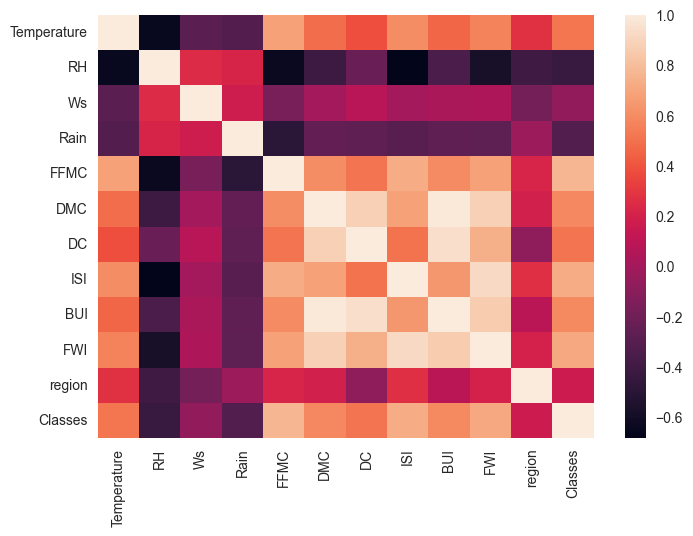

In [137]:
sns.heatmap(df_copy.corr())

<Axes: ylabel='FWI'>

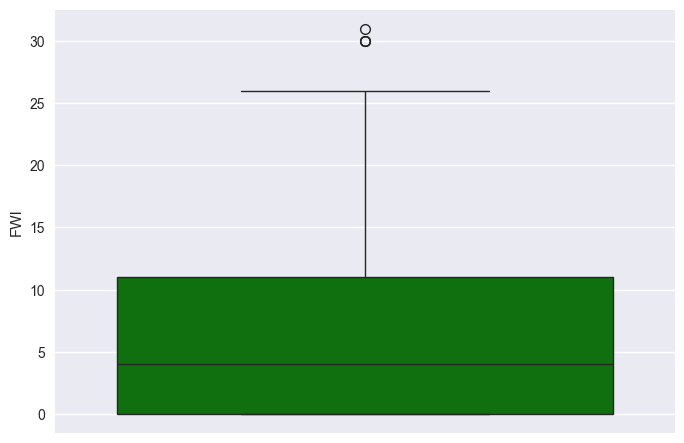

In [178]:
#box plot using 
sns.boxplot(df['FWI'],color='g')

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  region       243 non-null    int64  
dtypes: float64(7), int64(7), str(1)
memory usage: 28.6 KB


In [169]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

In [172]:
df.head(239)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,region
0,1,1,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,not fire,0
1,1,1,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,not fire,0
2,3,6,2012,26,82,22,13.0,47.0,2.0,7.0,0.0,2.0,0.0,not fire,0
3,4,6,2012,25,89,13,2.0,28.0,1.0,6.0,0.0,1.0,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.0,3.0,14.0,1.0,3.0,0.0,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,22,9,2012,33,64,13,0.0,88.0,26.0,106.0,7.0,32.0,13.0,fire,1
235,23,9,2012,35,56,14,0.0,89.0,29.0,115.0,7.0,36.0,15.0,fire,1
236,24,9,2012,26,49,6,2.0,61.0,11.0,28.0,0.0,11.0,0.0,not fire,1
237,25,9,2012,28,70,15,0.0,79.0,13.0,36.0,2.0,14.0,3.0,not fire,1


In [177]:
df.nunique()

day             31
month            5
year             2
Temperature     20
RH              63
Ws              19
Rain            12
FFMC            58
DMC             52
DC             102
ISI             20
BUI             52
FWI             28
Classes          2
region           2
dtype: int64

<Axes: xlabel='month', ylabel='count'>

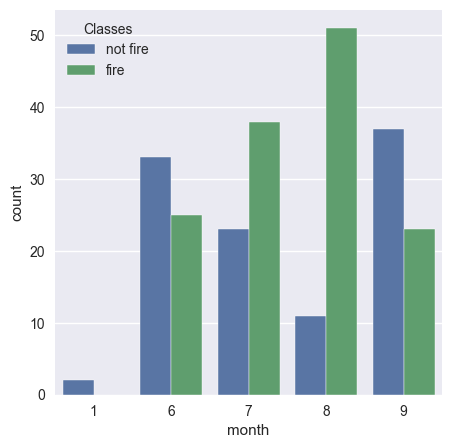

In [173]:
##monthly fire analysis
df_temp=df.iloc[df['region']==0]
plt.subplots(figsize=(5,5))
#sns.set_style('whitegrid')
sns.set_style("darkgrid")
sns.countplot(x='month',hue="Classes",data=df)

<Axes: xlabel='month', ylabel='count'>

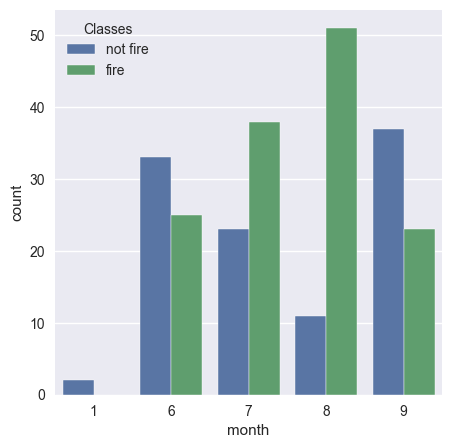

In [175]:
##monthly fire analysis
df_temp=df.iloc[df['region']==1]
plt.subplots(figsize=(5,5))
#sns.set_style('whitegrid')
sns.set_style("darkgrid")
sns.countplot(x='month',hue="Classes",data=df)